# Dataset Image Size Analysis

Reads all images from ArtDL, ICONCLASS, and wikidata and compares their size distributions.

In [17]:
import os
import statistics
from concurrent.futures import ThreadPoolExecutor, as_completed

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

Image.MAX_IMAGE_PIXELS = 200_000_000

BASE_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'dataset' else os.path.join(os.getcwd(), 'dataset')
# Allow running from project root or from dataset/
if not os.path.exists(os.path.join(BASE_DIR, 'ArtDL')):
    BASE_DIR = os.getcwd()

DATASETS = {
    'ArtDL':     os.path.join(BASE_DIR, 'ArtDL',     'JPEGImages'),
    'ICONCLASS':  os.path.join(BASE_DIR, 'ICONCLASS',  'JPEGImages'),
    'wikidata':  os.path.join(BASE_DIR, 'wikidata',  'JPEGImages'),
}

# Only consider images actually used in evaluation (from 2_test.txt)
DATA_DIRS = {
    'ArtDL':    os.path.join(BASE_DIR, 'ArtDL-data'),
    'ICONCLASS': os.path.join(BASE_DIR, 'ICONCLASS-data'),
    'wikidata': os.path.join(BASE_DIR, 'wikidata-data'),
}

COLORS = {'ArtDL': '#4C72B0', 'ICONCLASS': '#DD8452', 'wikidata': '#55A868'}

def load_test_ids(data_dir):
    """Return the set of image IDs listed in 2_test.txt."""
    test_file = os.path.join(data_dir, '2_test.txt')
    with open(test_file) as f:
        return set(f.read().splitlines())

## Load image dimensions

In [18]:
def read_sizes(directory, allowed_ids=None, workers=8):
    """Return list of (width, height) for images in directory.
    
    If allowed_ids is provided, only images whose stem (filename without extension)
    is in allowed_ids are read.
    """
    files = [
        os.path.join(directory, f)
        for f in os.listdir(directory)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))
        and (allowed_ids is None or os.path.splitext(f)[0] in allowed_ids)
    ]

    sizes = []
    errors = []

    def _read(path):
        try:
            with Image.open(path) as img:
                return img.size  # (width, height)
        except Exception:
            return None

    with ThreadPoolExecutor(max_workers=workers) as ex:
        futures = {ex.submit(_read, f): f for f in files}
        for fut in tqdm(as_completed(futures), total=len(files), desc=os.path.basename(os.path.dirname(directory))):
            result = fut.result()
            if result:
                sizes.append(result)
            else:
                errors.append(futures[fut])

    if errors:
        print(f"  {len(errors)} unreadable file(s) skipped")
    return sizes


data = {}
for name, path in DATASETS.items():
    test_ids = load_test_ids(DATA_DIRS[name])
    print(f"Reading {name} ({len(test_ids)} test images)...")
    data[name] = read_sizes(path, allowed_ids=test_ids)

Reading ArtDL (1864 test images)...


ArtDL: 100%|██████████| 1864/1864 [00:00<00:00, 2153.16it/s]


Reading ICONCLASS (863 test images)...


ICONCLASS: 100%|██████████| 863/863 [00:00<00:00, 2086.86it/s]


Reading wikidata (717 test images)...


wikidata: 100%|██████████| 717/717 [00:00<00:00, 2099.47it/s]


## Summary table

In [19]:
import tabulate as tab

BUCKET_EDGES = [0, 400, 1000, 3000, float('inf')]
BUCKET_LABELS = ['<400 px', '400–1000 px', '1000–3000 px', '≥3000 px']

rows = []
for name, sizes in data.items():
    ws = [w for w, h in sizes]
    hs = [h for w, h in sizes]
    longest = [max(w, h) for w, h in sizes]
    mp = [w * h / 1e6 for w, h in sizes]

    buckets = []
    for lo, hi in zip(BUCKET_EDGES, BUCKET_EDGES[1:]):
        buckets.append(sum(1 for v in longest if lo <= v < hi))

    rows.append([
        name,
        len(sizes),
        f"{statistics.median(ws):.0f}",
        f"{statistics.median(hs):.0f}",
        f"{np.mean(ws):.0f} ± {np.std(ws):.0f}",
        f"{np.mean(hs):.0f} ± {np.std(hs):.0f}",
        f"{statistics.median(mp):.2f}",
        f"{max(ws)}×{max(hs)}",
        *buckets,
    ])

headers = [
    'Dataset', 'Count',
    'Width (median)', 'Height (median)',
    'Width (mean ± std)', 'Height (mean ± std)',
    'MP (median)', 'Max size',
    *BUCKET_LABELS,
]

print(tab.tabulate(rows, headers=headers, tablefmt='github'))

| Dataset   |   Count |   Width (median) |   Height (median) | Width (mean ± std)   | Height (mean ± std)   |   MP (median) | Max size   |   <400 px |   400–1000 px |   1000–3000 px |   ≥3000 px |
|-----------|---------|------------------|-------------------|----------------------|-----------------------|---------------|------------|-----------|---------------|----------------|------------|
| ArtDL     |    1864 |              600 |               787 | 643 ± 110            | 793 ± 205             |          0.48 | 1801×2675  |         0 |          1691 |            173 |          0 |
| ICONCLASS |     863 |              355 |               500 | 371 ± 78             | 483 ± 42              |          0.17 | 500×500    |         2 |           861 |              0 |          0 |
| wikidata  |     717 |              611 |               800 | 602 ± 153            | 735 ± 117             |          0.46 | 800×800    |         2 |           715 |              0 |          0 |


## Width and height distributions

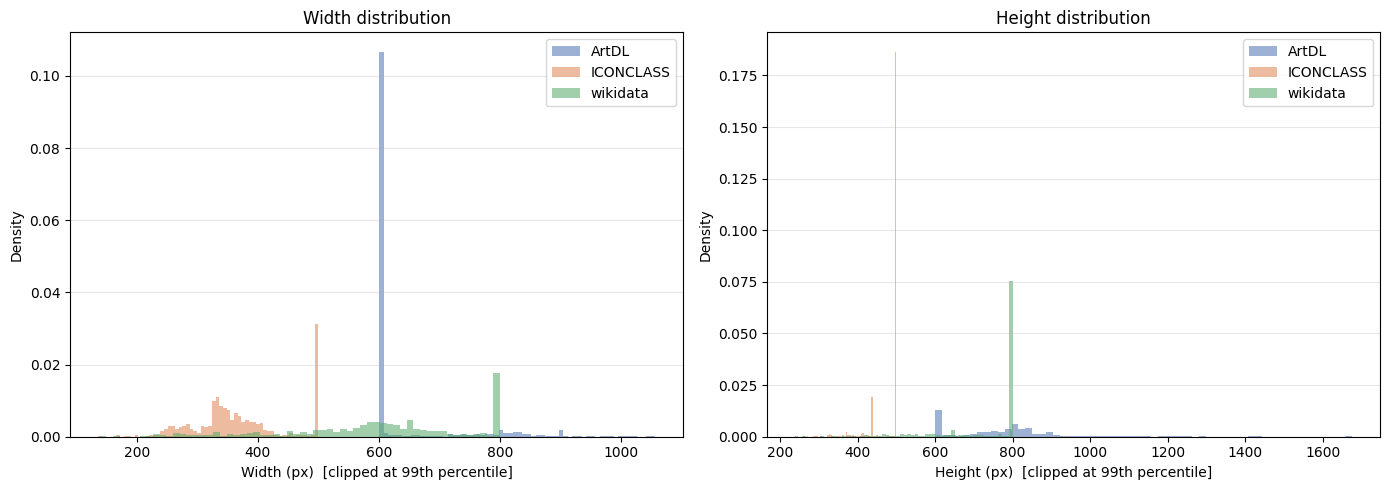

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, sizes in data.items():
    ws = [w for w, h in sizes]
    hs = [h for w, h in sizes]
    color = COLORS[name]

    # clip extreme tails for readability
    p99_w = np.percentile(ws, 99)
    p99_h = np.percentile(hs, 99)

    axes[0].hist([w for w in ws if w <= p99_w], bins=60, alpha=0.55,
                 color=color, label=name, density=True)
    axes[1].hist([h for h in hs if h <= p99_h], bins=60, alpha=0.55,
                 color=color, label=name, density=True)

for ax, dim in zip(axes, ['Width', 'Height']):
    ax.set_xlabel(f'{dim} (px)  [clipped at 99th percentile]')
    ax.set_ylabel('Density')
    ax.set_title(f'{dim} distribution')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'analysis', 'image_size_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

## Longest-side bucket comparison

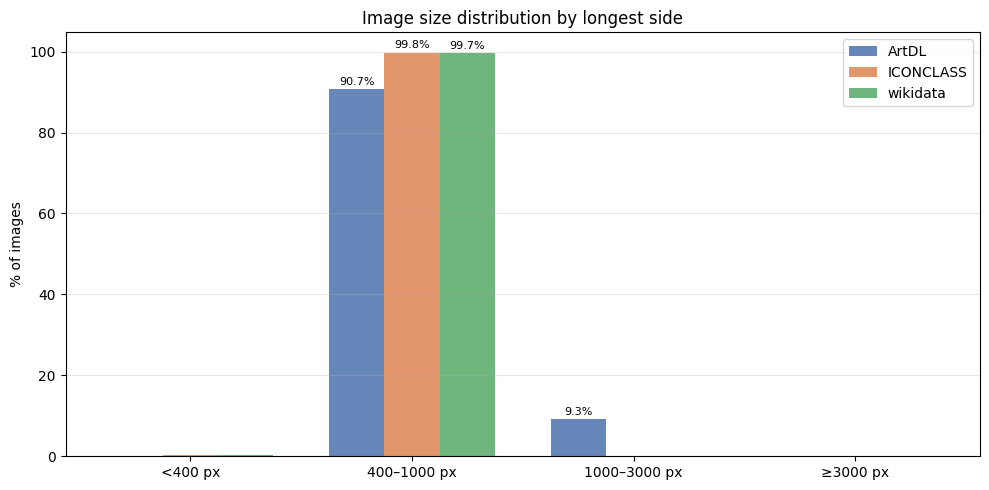

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

names = list(data.keys())
x = np.arange(len(BUCKET_LABELS))
width = 0.25

for i, name in enumerate(names):
    sizes = data[name]
    longest = [max(w, h) for w, h in sizes]
    counts = [
        sum(1 for v in longest if lo <= v < hi)
        for lo, hi in zip(BUCKET_EDGES, BUCKET_EDGES[1:])
    ]
    pcts = [c / len(sizes) * 100 for c in counts]
    bars = ax.bar(x + i * width, pcts, width, label=name, color=COLORS[name], alpha=0.85)
    for bar, pct in zip(bars, pcts):
        if pct > 1:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(BUCKET_LABELS)
ax.set_ylabel('% of images')
ax.set_title('Image size distribution by longest side')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'analysis', 'image_size_buckets.png'), dpi=150, bbox_inches='tight')
plt.show()

## Width vs height scatter

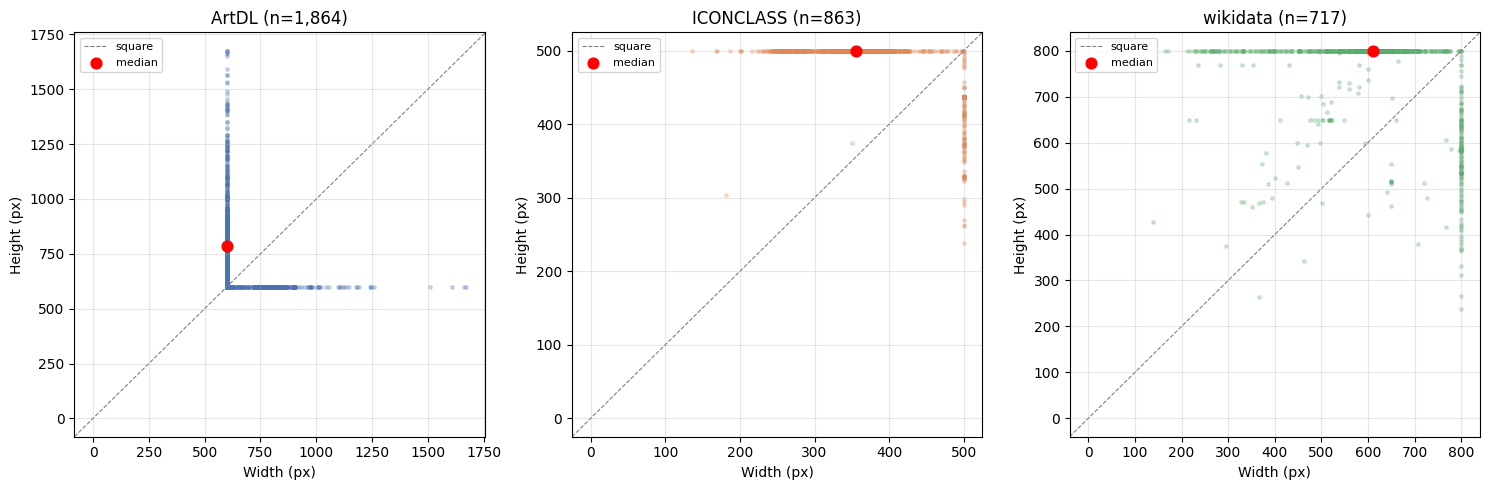

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=False, sharey=False)

for ax, (name, sizes) in zip(axes, data.items()):
    ws = np.array([w for w, h in sizes])
    hs = np.array([h for w, h in sizes])
    color = COLORS[name]

    # clip scatter to 99th percentile for readability
    cap = max(np.percentile(ws, 99), np.percentile(hs, 99))
    mask = (ws <= cap) & (hs <= cap)

    ax.scatter(ws[mask], hs[mask], alpha=0.25, s=6, color=color)
    ax.axline((0, 0), slope=1, color='grey', linewidth=0.8, linestyle='--', label='square')
    ax.scatter(np.median(ws), np.median(hs), color='red', s=60, zorder=5, label='median')
    ax.set_xlabel('Width (px)')
    ax.set_ylabel('Height (px)')
    ax.set_title(f'{name} (n={len(sizes):,})')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'analysis', 'image_size_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()

## Aspect ratio distribution

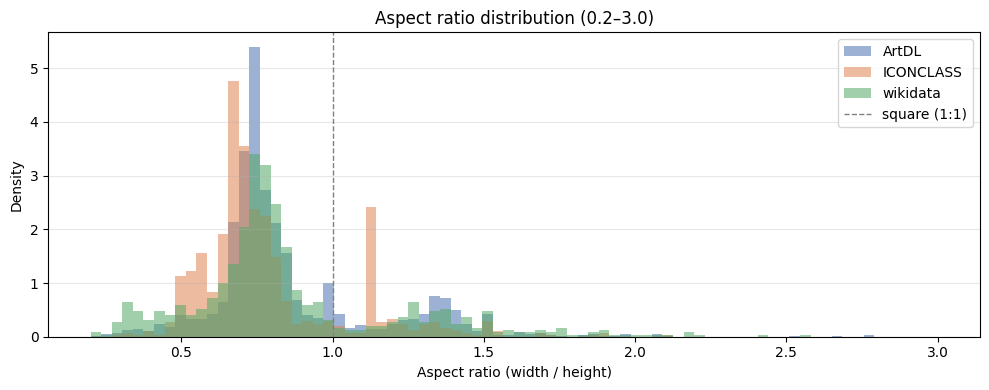

In [23]:
fig, ax = plt.subplots(figsize=(10, 4))

for name, sizes in data.items():
    ratios = [w / h for w, h in sizes]
    ax.hist(ratios, bins=80, range=(0.2, 3.0), alpha=0.55,
            color=COLORS[name], label=name, density=True)

ax.axvline(1.0, color='grey', linewidth=1, linestyle='--', label='square (1:1)')
ax.set_xlabel('Aspect ratio (width / height)')
ax.set_ylabel('Density')
ax.set_title('Aspect ratio distribution (0.2–3.0)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'analysis', 'image_aspect_ratios.png'), dpi=150, bbox_inches='tight')
plt.show()

## Megapixel distribution (log scale)

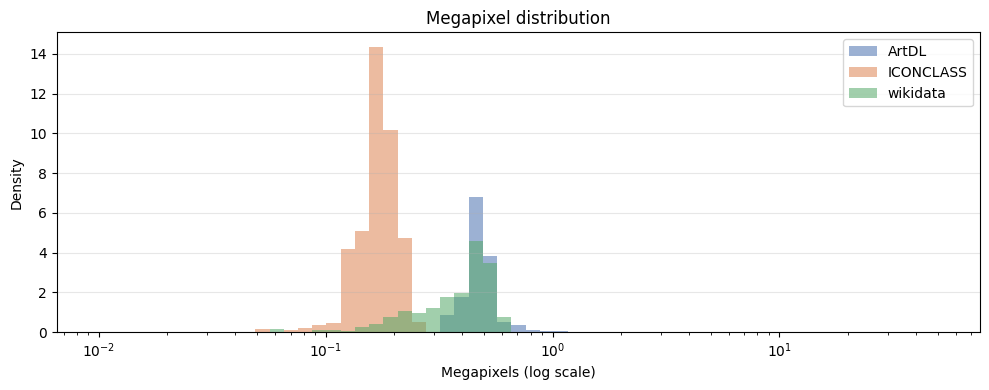

In [24]:
fig, ax = plt.subplots(figsize=(10, 4))

for name, sizes in data.items():
    mp = [w * h / 1e6 for w, h in sizes]
    ax.hist(mp, bins=np.logspace(np.log10(0.01), np.log10(50), 60),
            alpha=0.55, color=COLORS[name], label=name, density=True)

ax.set_xscale('log')
ax.set_xlabel('Megapixels (log scale)')
ax.set_ylabel('Density')
ax.set_title('Megapixel distribution')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'analysis', 'image_megapixels.png'), dpi=150, bbox_inches='tight')
plt.show()